<a href="https://colab.research.google.com/github/amruthachintada/Credit_Scoring_Model.ipynb/blob/main/Spam_Email_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving spam.csv to spam.csv
First 5 Rows
  Label                                            Message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Dataset Shape: (5572, 2)

Class Distribution
Label
ham     4825
spam     747
Name: count, dtype: int64

Accuracy: 96.86 %

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115


Confusion Matrix
[[965   0]
 [ 35 115]]


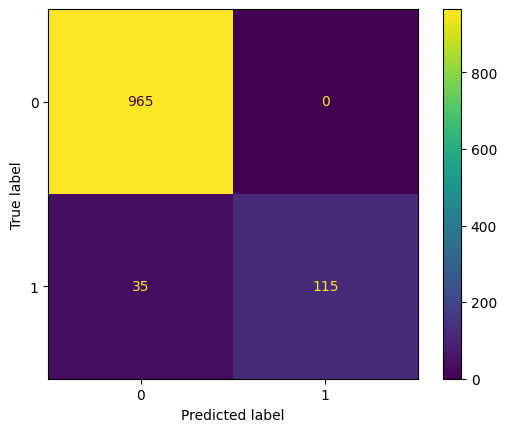


Prediction : SPAM

Enter Your Own Message
Congratulations! You have won ₹50,000. Click here to claim your prize.

Result : SPAM MESSAGE

Task Completed Successfully!


In [1]:
# =====================================================
# CodeAlpha Internship
# Task 2 : Spam Email Detection
# =====================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# -----------------------------------------------------
# Upload Dataset
# -----------------------------------------------------
from google.colab import files

uploaded = files.upload()

# -----------------------------------------------------
# Load Dataset
# -----------------------------------------------------
df = pd.read_csv(
    "spam.csv",
    encoding="latin-1"
)

# Keep only useful columns
df = df[['v1','v2']]

df.columns = ['Label','Message']

print("First 5 Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nClass Distribution")
print(df['Label'].value_counts())

# -----------------------------------------------------
# Convert Labels
# ham = 0
# spam = 1
# -----------------------------------------------------
df['Label'] = df['Label'].map({
    'ham':0,
    'spam':1
})

# -----------------------------------------------------
# Features & Labels
# -----------------------------------------------------
X = df['Message']
y = df['Label']

# -----------------------------------------------------
# Convert Text into Numbers
# -----------------------------------------------------
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(X)

# -----------------------------------------------------
# Train Test Split
# -----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------------------------
# Train Model
# -----------------------------------------------------
model = MultinomialNB()

model.fit(X_train, y_train)

# -----------------------------------------------------
# Prediction
# -----------------------------------------------------
y_pred = model.predict(X_test)

# -----------------------------------------------------
# Accuracy
# -----------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy*100,2),"%")

# -----------------------------------------------------
# Classification Report
# -----------------------------------------------------
print("\nClassification Report")

print(classification_report(y_test,y_pred))

# -----------------------------------------------------
# Confusion Matrix
# -----------------------------------------------------
cm = confusion_matrix(y_test,y_pred)

print("\nConfusion Matrix")

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

# -----------------------------------------------------
# Predict Custom Message
# -----------------------------------------------------

message = [
    "Congratulations! You have won a free iPhone. Click here to claim your prize."
]

message_vector = vectorizer.transform(message)

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("\nPrediction : SPAM")
else:
    print("\nPrediction : HAM")

# -----------------------------------------------------
# User Input Prediction
# -----------------------------------------------------

print("\nEnter Your Own Message")

user_message = input()

user_vector = vectorizer.transform([user_message])

pred = model.predict(user_vector)

if pred[0] == 1:
    print("\nResult : SPAM MESSAGE")
else:
    print("\nResult : NOT SPAM")

print("\nTask Completed Successfully!")